# Nghiên Cứu Thuật Toán XGBoost - Phân Loại Ung Thư Vú
## Dataset: UCI Breast Cancer Wisconsin Diagnostic

**Nội dung notebook:**
1. Tải và khám phá dataset
2. Tiền xử lý và trực quan hóa dữ liệu
3. Chia tập train/test
4. Huấn luyện và so sánh các mô hình (Decision Tree, Random Forest, Logistic Regression, KNN, XGBoost)
5. (Phụ) Tìm kiếm siêu tham số tối ưu (GridSearchCV)
6. Phân tích ảnh hưởng tham số XGBoost
7. Feature Importance
8. So sánh kết quả tổng hợp

## 1. Import Thư Viện

### Cài đặt thư viện (nếu cần)

```bash
pip install scikit-learn xgboost pandas numpy matplotlib seaborn
```

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, make_scorer,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
 )
from xgboost import XGBClassifier

# Thiết lập style biểu đồ
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

RANDOM_STATE = 42
print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


## 2. Tải và Khám Phá Dataset

In [ ]:
# Tải dataset từ sklearn (UCI Breast Cancer Wisconsin Diagnostic)
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = Malignant, 1 = Benign trong sklearn (theo protocol)

POS_LABEL = 0
NEG_LABEL = 1
POS_NAME = 'Malignant'
NEG_NAME = 'Benign'

print('=' * 60)
print(f'  DATASET: UCI Breast Cancer Wisconsin Diagnostic')
print('=' * 60)
print(f'  Số mẫu (samples)  : {df.shape[0]}')
print(f'  Số đặc trưng      : {df.shape[1] - 1}')
print(f'  Giá trị thiếu     : {df.isnull().sum().sum()}')
print(f'  {POS_NAME} ({POS_LABEL}) : {(df.target == POS_LABEL).sum()} mẫu ({(df.target==POS_LABEL).mean()*100:.1f}%)')
print(f'  {NEG_NAME} ({NEG_LABEL})  : {(df.target == NEG_LABEL).sum()} mẫu ({(df.target==NEG_LABEL).mean()*100:.1f}%)')
print('=' * 60)

df.head()

  DATASET: UCI Breast Cancer Wisconsin Diagnostic
  Số mẫu (samples)  : 569
  Số đặc trưng      : 30
  Giá trị thiếu     : 0
  Malignant (1)     : 212 mẫu (37.3%)
  Benign (0)        : 357 mẫu (62.7%)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [3]:
# Thống kê mô tả
print('Thống kê mô tả 10 đặc trưng đầu:')
df.iloc[:, :10].describe().round(3)

Thống kê mô tả 10 đặc trưng đầu:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097


## 3. Trực Quan Hóa Dữ Liệu (EDA)

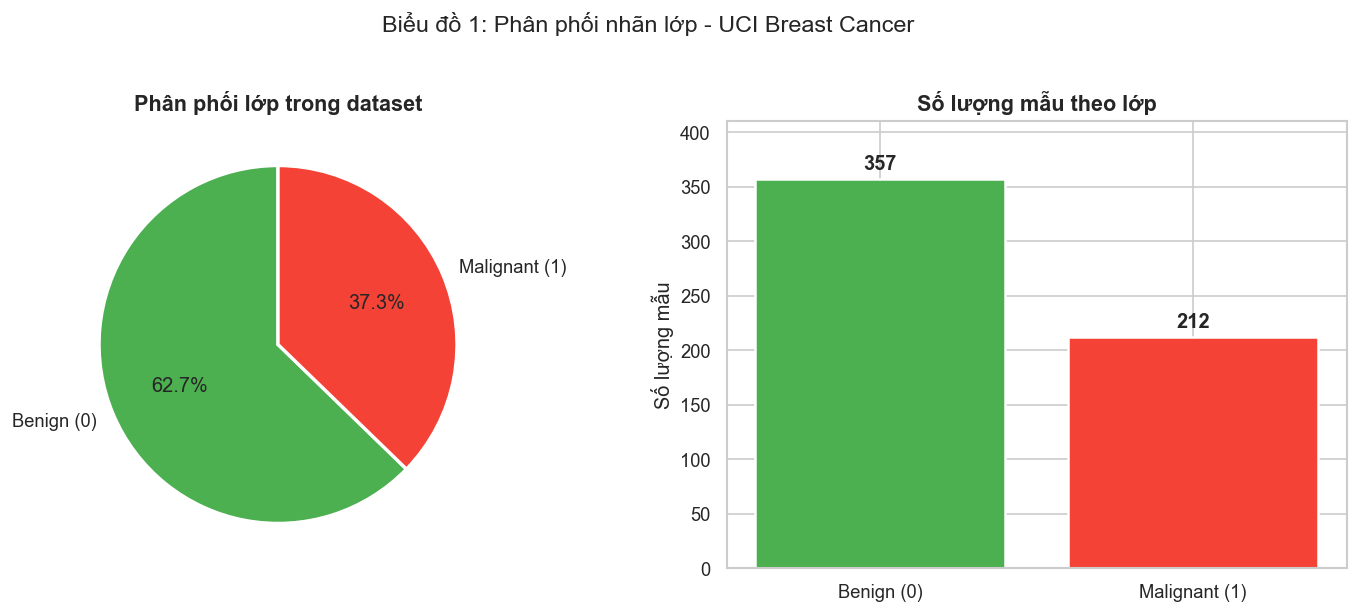

In [ ]:
# Biểu đồ 1: Phân phối lớp
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
counts = df['target'].value_counts().sort_index()
class_names = [f'{POS_NAME} ({POS_LABEL})', f'{NEG_NAME} ({NEG_LABEL})']
colors = ['#F44336', '#4CAF50']
axes[0].pie(counts, labels=class_names, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Phân phối lớp trong dataset', fontsize=13, fontweight='bold')

# Bar chart
bars = axes[1].bar(class_names, counts, color=colors, edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].set_title('Số lượng mẫu theo lớp', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Số lượng mẫu')
axes[1].set_ylim(0, max(counts) * 1.15)

plt.suptitle('Biểu đồ 1: Phân phối nhãn lớp - UCI Breast Cancer', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

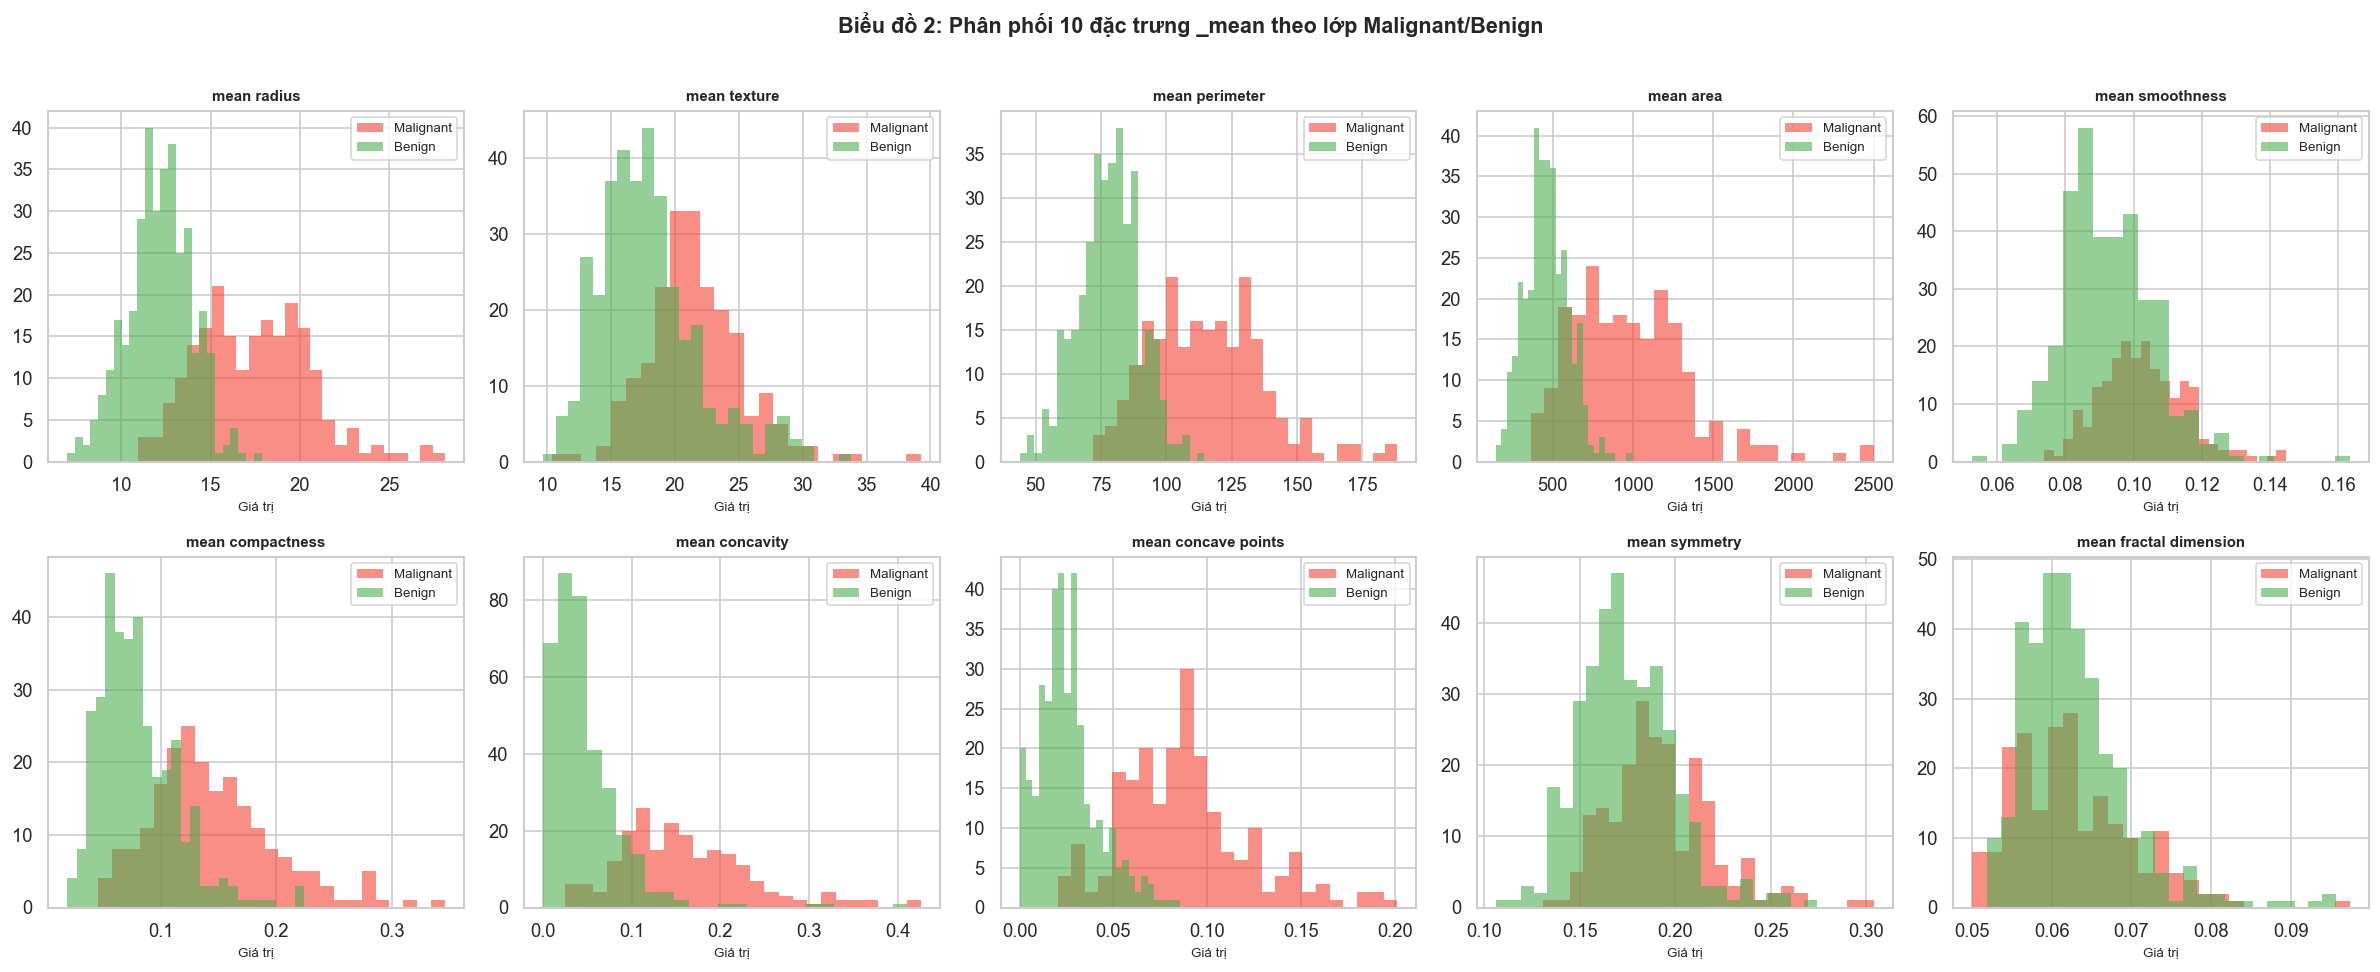

In [ ]:
# Biểu đồ 2: Phân phối của 10 đặc trưng _mean theo lớp
mean_features = [col for col in df.columns if col.startswith('mean ')]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(mean_features):
    for label, color, name in [(POS_LABEL, '#F44336', POS_NAME), (NEG_LABEL, '#4CAF50', NEG_NAME)]:
        subset = df[df['target'] == label][feat]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color, label=name, edgecolor='none')
    axes[i].set_title(feat.replace(' (mean)', '\n(mean)'), fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Giá trị', fontsize=8)

plt.suptitle('Biểu đồ 2: Phân phối 10 đặc trưng _mean theo lớp Malignant/Benign',
             fontsize=13, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

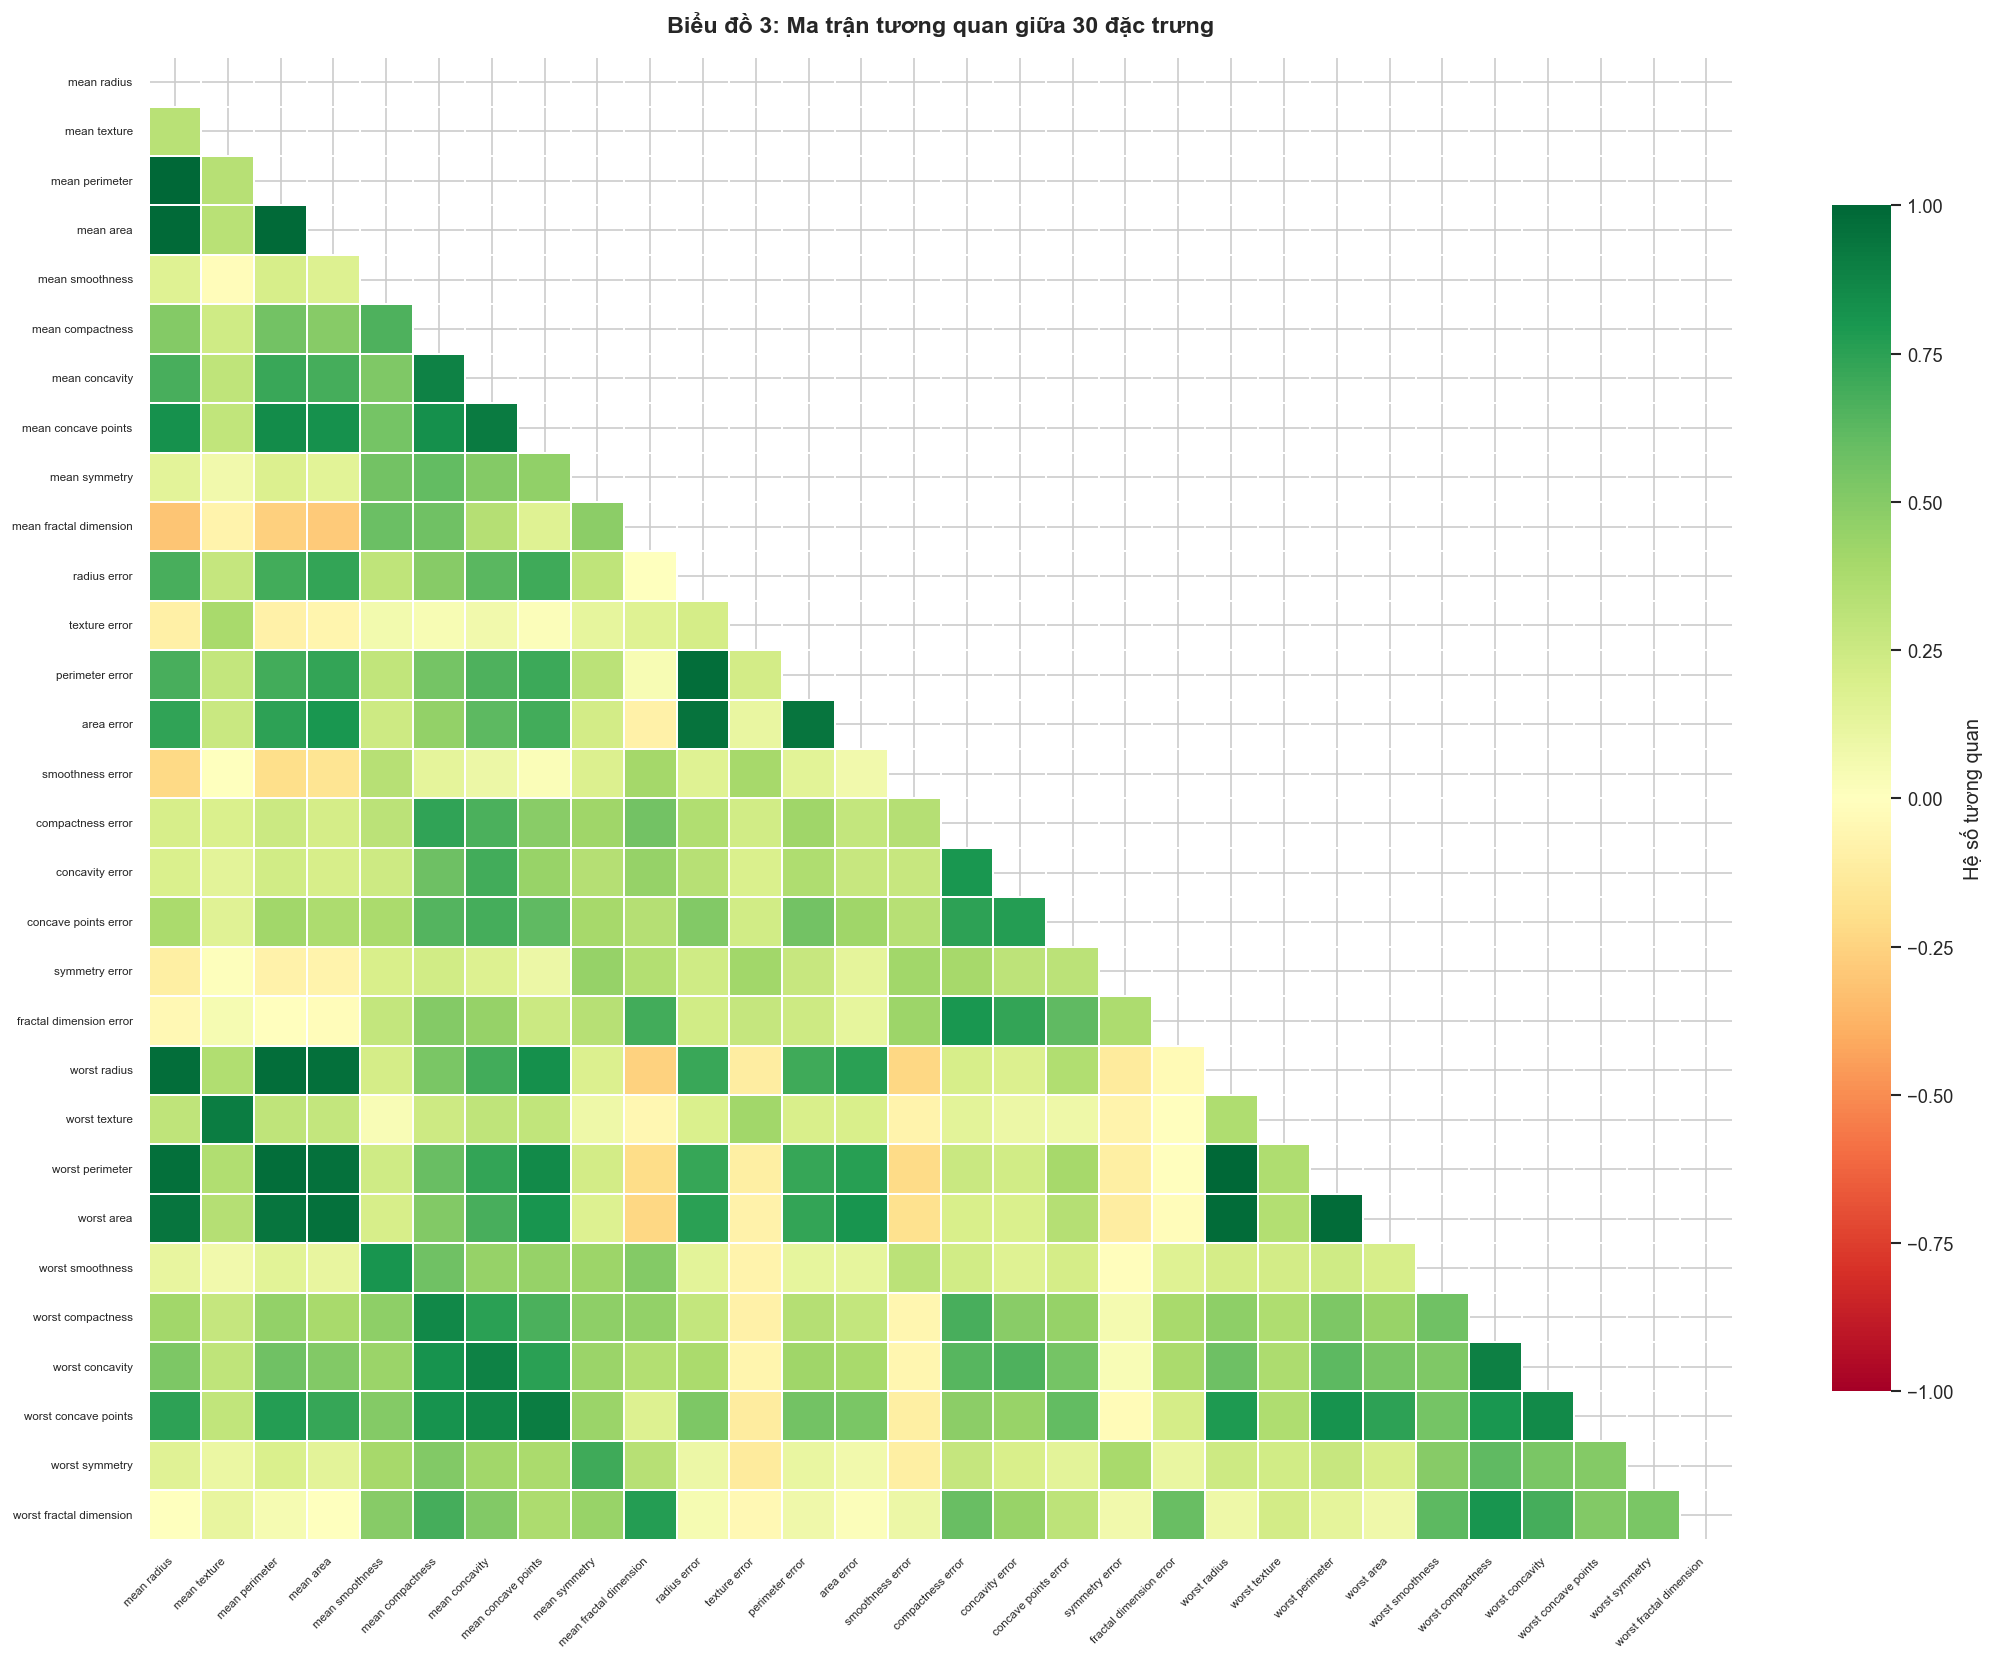

In [6]:
# Biểu đồ 3: Heatmap tương quan (30 đặc trưng)
fig, ax = plt.subplots(figsize=(18, 14))

corr_matrix = df.drop('target', axis=1).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.1, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Hệ số tương quan'})

ax.set_title('Biểu đồ 3: Ma trận tương quan giữa 30 đặc trưng',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

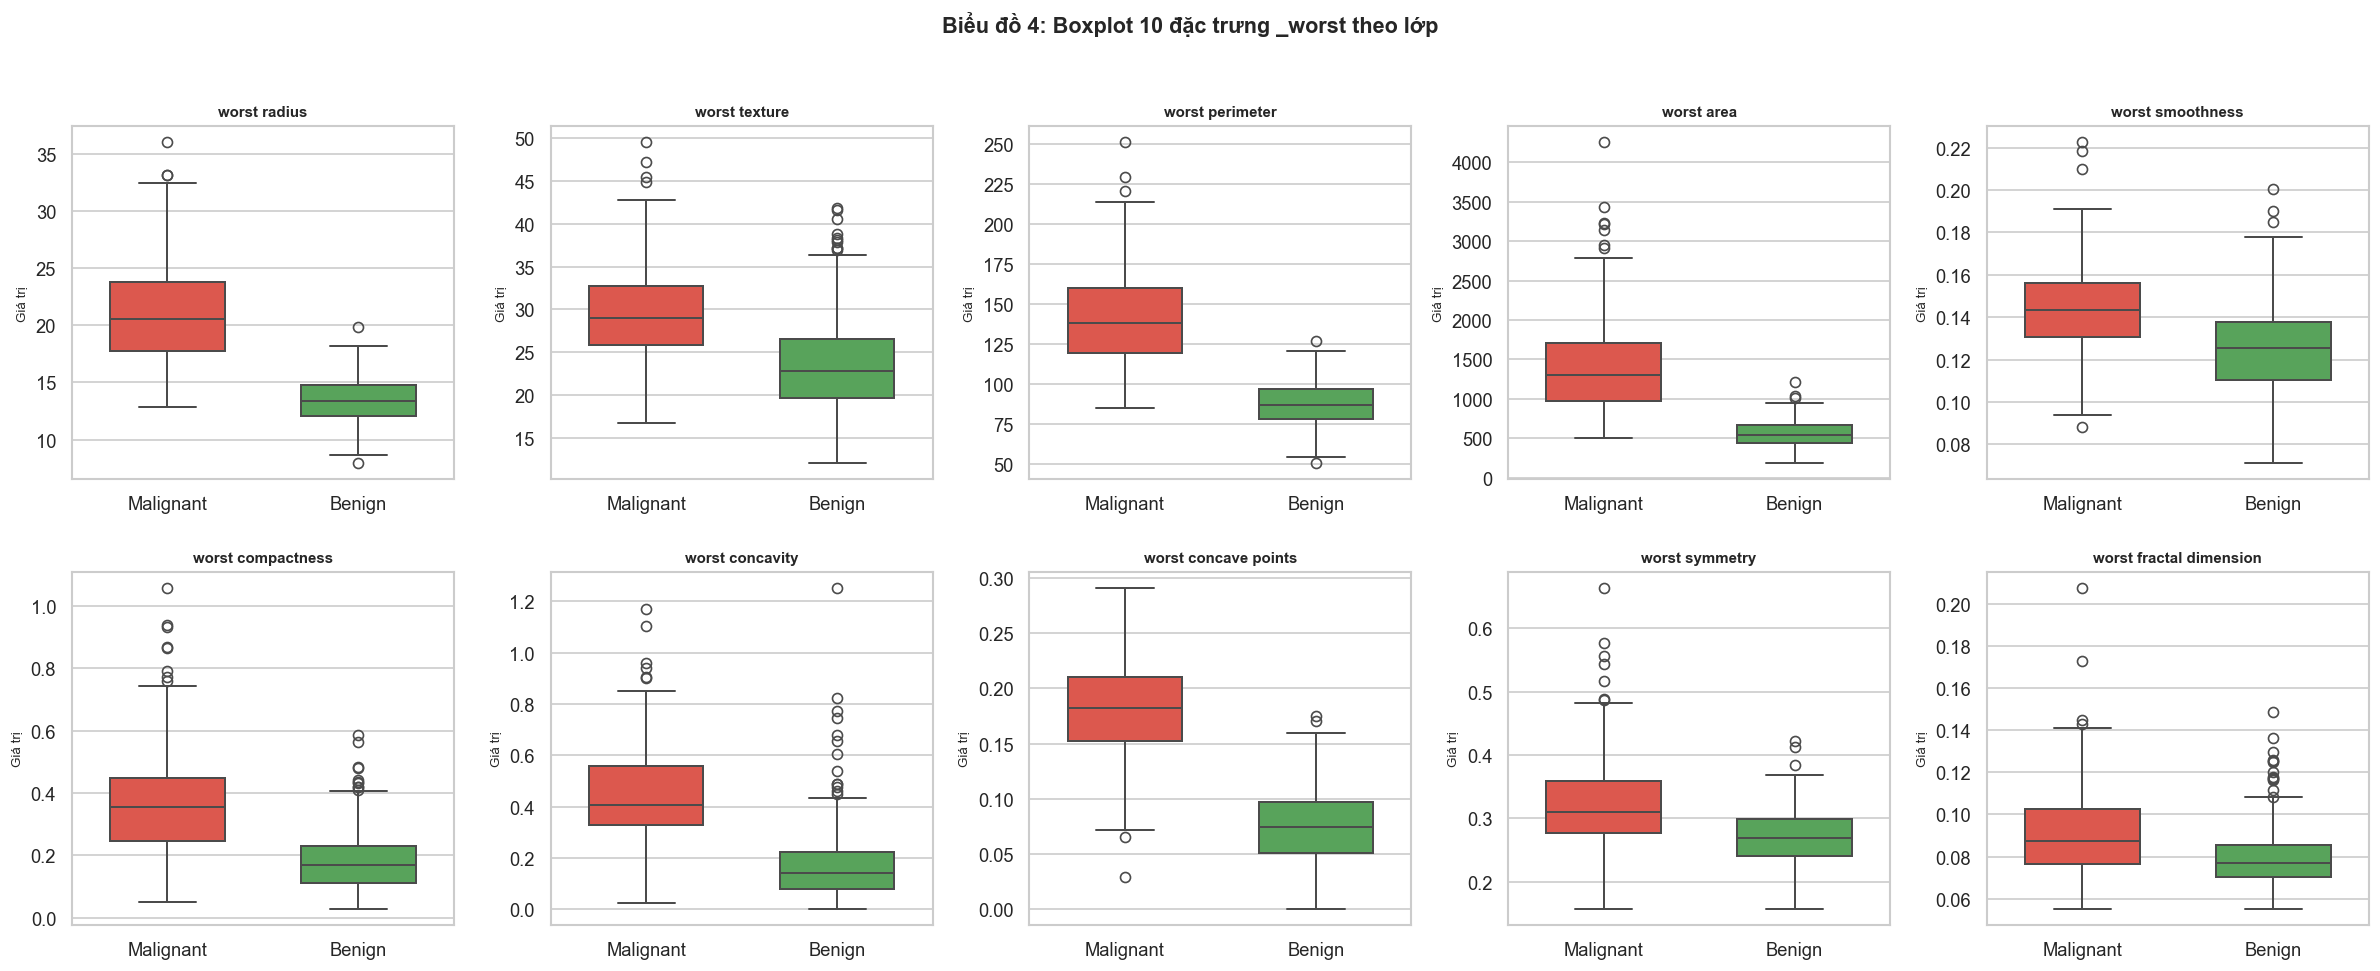

In [ ]:
# Biểu đồ 4: Boxplot các đặc trưng _worst theo lớp
worst_features = [col for col in df.columns if col.startswith('worst ')]
df_melt = df[worst_features + ['target']].melt(id_vars='target', var_name='feature', value_name='value')
label_map = {POS_LABEL: POS_NAME, NEG_LABEL: NEG_NAME}
df_melt['label'] = df_melt['target'].map(label_map)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
palette = {POS_NAME: '#F44336', NEG_NAME: '#4CAF50'}

for i, feat in enumerate(worst_features):
    subset = df[['target', feat]].copy()
    subset['label'] = subset['target'].map(label_map)
    sns.boxplot(data=subset, x='label', y=feat, palette=palette,
                ax=axes[i], width=0.6, linewidth=1.2)
    axes[i].set_title(feat.replace('worst', '\nworst'), fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Giá trị', fontsize=8)

plt.suptitle('Biểu đồ 4: Boxplot 10 đặc trưng _worst theo lớp',
             fontsize=13, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

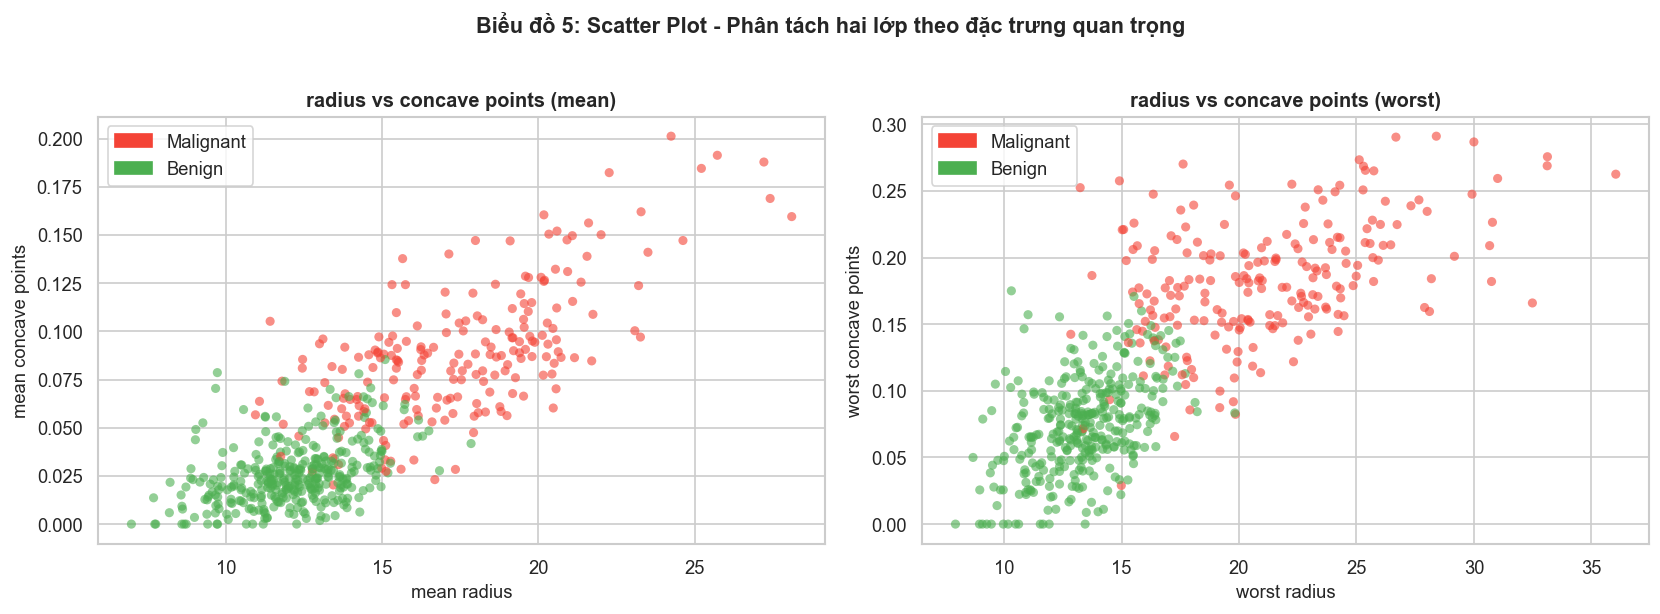

In [ ]:
# Biểu đồ 5: Scatter plot 2 đặc trưng quan trọng nhất
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_map = {POS_LABEL: '#F44336', NEG_LABEL: '#4CAF50'}
colors_list = df['target'].map(colors_map)

# Scatter 1: radius_mean vs concave points_mean
scatter1 = axes[0].scatter(df['mean radius'], df['mean concave points'],
                           c=colors_list, alpha=0.6, s=30, edgecolors='none')
axes[0].set_xlabel('mean radius', fontsize=11)
axes[0].set_ylabel('mean concave points', fontsize=11)
axes[0].set_title('radius vs concave points (mean)', fontsize=12, fontweight='bold')
patch_pos = mpatches.Patch(color='#F44336', label=POS_NAME)
patch_neg = mpatches.Patch(color='#4CAF50', label=NEG_NAME)
axes[0].legend(handles=[patch_pos, patch_neg])

# Scatter 2: worst radius vs worst concave points
axes[1].scatter(df['worst radius'], df['worst concave points'],
                c=colors_list, alpha=0.6, s=30, edgecolors='none')
axes[1].set_xlabel('worst radius', fontsize=11)
axes[1].set_ylabel('worst concave points', fontsize=11)
axes[1].set_title('radius vs concave points (worst)', fontsize=12, fontweight='bold')
axes[1].legend(handles=[patch_pos, patch_neg])

plt.suptitle('Biểu đồ 5: Scatter Plot - Phân tách hai lớp theo đặc trưng quan trọng',
             fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Chia Tập Train/Test

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Tổng số mẫu       : {len(y)}')
print(f'Tập huấn luyện    : {len(y_train)} mẫu ({len(y_train)/len(y)*100:.1f}%)')
print(f'Tập kiểm tra      : {len(y_test)} mẫu ({len(y_test)/len(y)*100:.1f}%)')
print()
print(f'Train - {POS_NAME} : {(y_train == POS_LABEL).sum()} ({(y_train==POS_LABEL).mean()*100:.1f}%)')
print(f'Train - {NEG_NAME}  : {(y_train==NEG_LABEL).sum()} ({(y_train==NEG_LABEL).mean()*100:.1f}%)')
print(f'Test  - {POS_NAME} : {(y_test == POS_LABEL).sum()} ({(y_test==POS_LABEL).mean()*100:.1f}%)')
print(f'Test  - {NEG_NAME}  : {(y_test==NEG_LABEL).sum()} ({(y_test==NEG_LABEL).mean()*100:.1f}%)')

Tổng số mẫu       : 569
Tập huấn luyện    : 398 mẫu (69.9%)
Tập kiểm tra      : 171 mẫu (30.1%)

Train - Malignant : 148 (37.2%)
Train - Benign    : 250 (62.8%)
Test  - Malignant : 64 (37.4%)
Test  - Benign    : 107 (62.6%)


## 5. Huấn Luyện Và Đánh Giá Các Mô Hình

In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Huấn luyện và đánh giá mô hình, trả về dict kết quả."""
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    pos_index = int(np.where(model.classes_ == POS_LABEL)[0][0])
    y_proba_test = model.predict_proba(X_test)[:, pos_index]
    y_proba_train = model.predict_proba(X_train)[:, pos_index]

    y_test_pos = (y_test == POS_LABEL).astype(int)
    y_train_pos = (y_train == POS_LABEL).astype(int)

    cm = confusion_matrix(y_test, y_pred_test, labels=[POS_LABEL, NEG_LABEL])
    false_negatives = int(cm[0, 1])

    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred_test),
        'Precision': precision_score(y_test, y_pred_test, pos_label=POS_LABEL),
        'Recall': recall_score(y_test, y_pred_test, pos_label=POS_LABEL),
        'F1-score': f1_score(y_test, y_pred_test, pos_label=POS_LABEL),
        'ROC-AUC': roc_auc_score(y_test_pos, y_proba_test),
        'Train F1-score': f1_score(y_train, y_pred_train, pos_label=POS_LABEL),
        'Train ROC-AUC': roc_auc_score(y_train_pos, y_proba_train),
        'False Negatives': false_negatives,
        'Training Time (s)': round(train_time, 4),
        'y_pred': y_pred_test,
        'y_proba': y_proba_test,
        'model_obj': model
    }
    return results


# ---- Định nghĩa các mô hình ----
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost (default)': XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        subsample=1.0, colsample_bytree=1.0,
        objective='binary:logistic',
        random_state=RANDOM_STATE, eval_metric='logloss',
        use_label_encoder=False, verbosity=0
    ),
    'Logistic Regression': LogisticRegression(max_iter=10000, random_state=RANDOM_STATE),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5)
}

# Chuẩn hóa cho Logistic Regression và KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---- Huấn luyện ----
all_results = []
for name, model in models.items():
    if name in ('Logistic Regression', 'KNN (k=5)'):
        result = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test, name)
    else:
        result = evaluate_model(model, X_train, X_test, y_train, y_test, name)
    all_results.append(result)
    print(f' {name:25s} | Acc={result["Accuracy"]:.4f} | F1(test)={result["F1-score"]:.4f} | AUC(test)={result["ROC-AUC"]:.4f} | FN={result["False Negatives"]:3d} | Time={result["Training Time (s)"]:.4f}s')

print('\n✅ Huấn luyện hoàn thành!')

 Decision Tree             | Acc=0.9006 | F1=0.8640 | AUC=0.8892 | Time=0.0145s
 Random Forest             | Acc=0.9649 | F1=0.9508 | AUC=0.9968 | Time=0.1485s
 XGBoost (default)         | Acc=0.9825 | F1=0.9760 | AUC=0.9956 | Time=2.2138s
 Logistic Regression       | Acc=0.9708 | F1=0.9600 | AUC=0.9975 | Time=0.0228s
 KNN (k=5)                 | Acc=0.9649 | F1=0.9508 | AUC=0.9882 | Time=0.0010s

✅ Huấn luyện hoàn thành!


In [ ]:
# Bảng so sánh kết quả
metrics_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'False Negatives', 'Training Time (s)']
df_results = pd.DataFrame(all_results)[metrics_cols]

# Format số thập phân
for col in ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']:
    df_results[col] = df_results[col].apply(lambda x: f'{x:.4f}')
df_results['False Negatives'] = df_results['False Negatives'].astype(int)

df_results.set_index('Model', inplace=True)
print('\n===== BẢNG SO SÁNH KẾT QUẢ CÁC MÔ HÌNH =====')
df_results


===== BẢNG SO SÁNH KẾT QUẢ CÁC MÔ HÌNH =====


,Accuracy,Precision,Recall,F1-score,ROC-AUC,Training Time (s)
Model,,,,,,
Decision Tree,0.9006,0.8852,0.8438,0.8640,0.8892,0.0145
Random Forest,0.9649,1.0000,0.9062,0.9508,0.9968,0.1485
XGBoost (default),0.9825,1.0000,0.9531,0.9760,0.9956,2.2138
Logistic Regression,0.9708,0.9836,0.9375,0.9600,0.9975,0.0228
KNN (k=5),0.9649,1.0000,0.9062,0.9508,0.9882,0.0010


In [ ]:
# Bảng overfitting (Train vs Test)
df_overfit = pd.DataFrame(all_results)[
    ['Model', 'Train F1-score', 'F1-score', 'Train ROC-AUC', 'ROC-AUC']
].rename(columns={
    'Train F1-score': 'Train F1',
    'F1-score': 'Test F1',
    'Train ROC-AUC': 'Train ROC-AUC',
    'ROC-AUC': 'Test ROC-AUC'
})

for col in ['Train F1', 'Test F1', 'Train ROC-AUC', 'Test ROC-AUC']:
    df_overfit[col] = df_overfit[col].apply(lambda x: f'{x:.4f}')

df_overfit.set_index('Model')

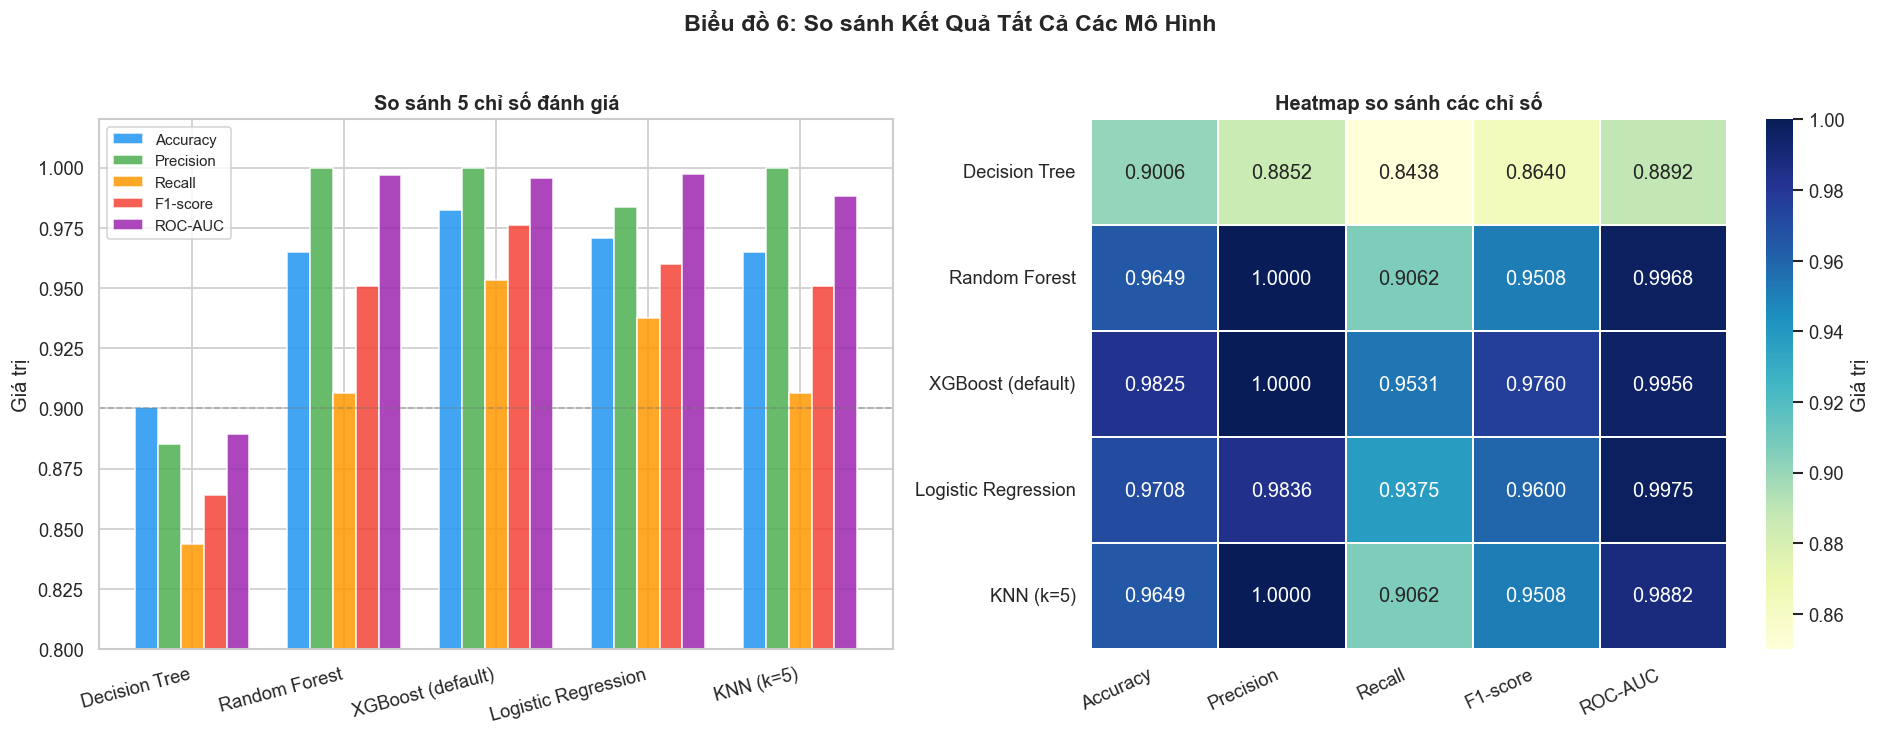

In [7]:
# Biểu đồ 6: So sánh các chỉ số đánh giá
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
model_names = [r['Model'] for r in all_results]
metric_values = {m: [r[m] for r in all_results] for m in metric_names}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bar chart
x = np.arange(len(model_names))
width = 0.15
colors_bar = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']

for i, (metric, color) in enumerate(zip(metric_names, colors_bar)):
    offset = (i - 2) * width
    bars = axes[0].bar(x + offset, metric_values[metric], width,
                       label=metric, color=color, alpha=0.85, edgecolor='white')

axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
axes[0].set_ylabel('Giá trị')
axes[0].set_ylim(0.8, 1.02)
axes[0].set_title('So sánh 5 chỉ số đánh giá', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Radar-like heatmap
df_heatmap = pd.DataFrame(
    {m: [r[m] for r in all_results] for m in metric_names},
    index=model_names
)
sns.heatmap(df_heatmap, annot=True, fmt='.4f', cmap='YlGnBu',
            vmin=0.85, vmax=1.0, ax=axes[1],
            linewidths=1, linecolor='white', cbar_kws={'label': 'Giá trị'})
axes[1].set_title('Heatmap so sánh các chỉ số', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=25, ha='right')

plt.suptitle('Biểu đồ 6: So sánh Kết Quả Tất Cả Các Mô Hình',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

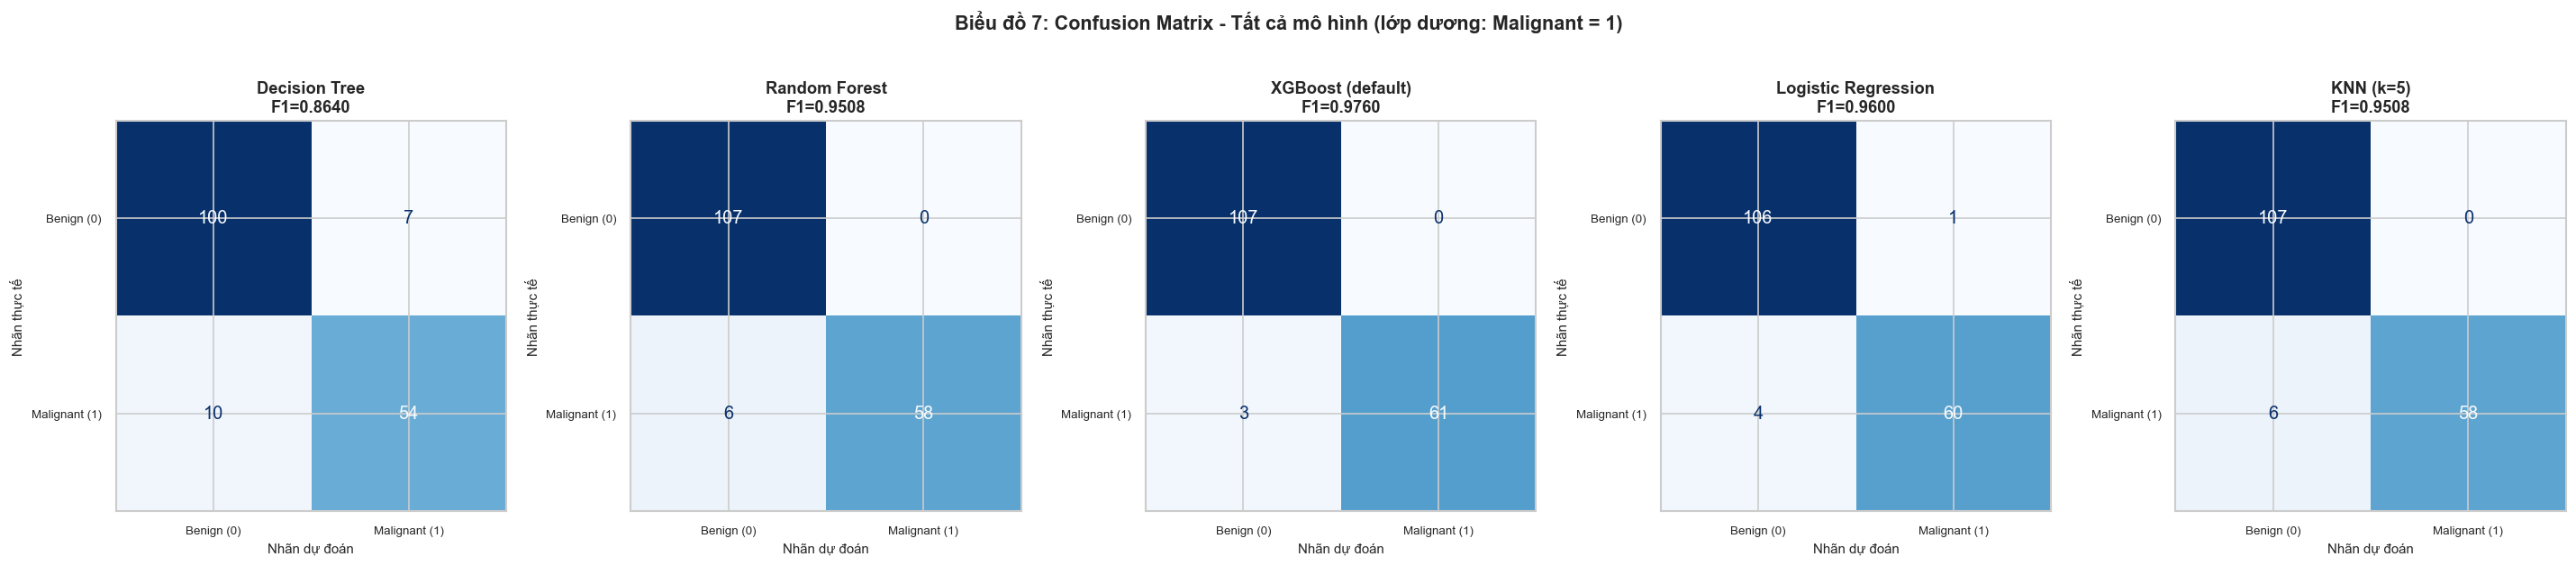

In [ ]:
# Biểu đồ 7: Confusion Matrix cho tất cả mô hình
fig, axes = plt.subplots(1, 5, figsize=(24, 5))
class_names = [f'{POS_NAME} ({POS_LABEL})', f'{NEG_NAME} ({NEG_LABEL})']

for i, result in enumerate(all_results):
    cm = confusion_matrix(y_test, result['y_pred'], labels=[POS_LABEL, NEG_LABEL])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{result["Model"]}\nF1={result["F1-score"]:.4f}',
                       fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Nhãn dự đoán', fontsize=9)
    axes[i].set_ylabel('Nhãn thực tế', fontsize=9)
    axes[i].xaxis.set_tick_params(labelsize=8)
    axes[i].yaxis.set_tick_params(labelsize=8)

plt.suptitle('Biểu đồ 7: Confusion Matrix - Tất cả mô hình (lớp dương: Malignant = 0)',
             fontsize=13, y=1.03, fontweight='bold')
plt.tight_layout()
plt.show()

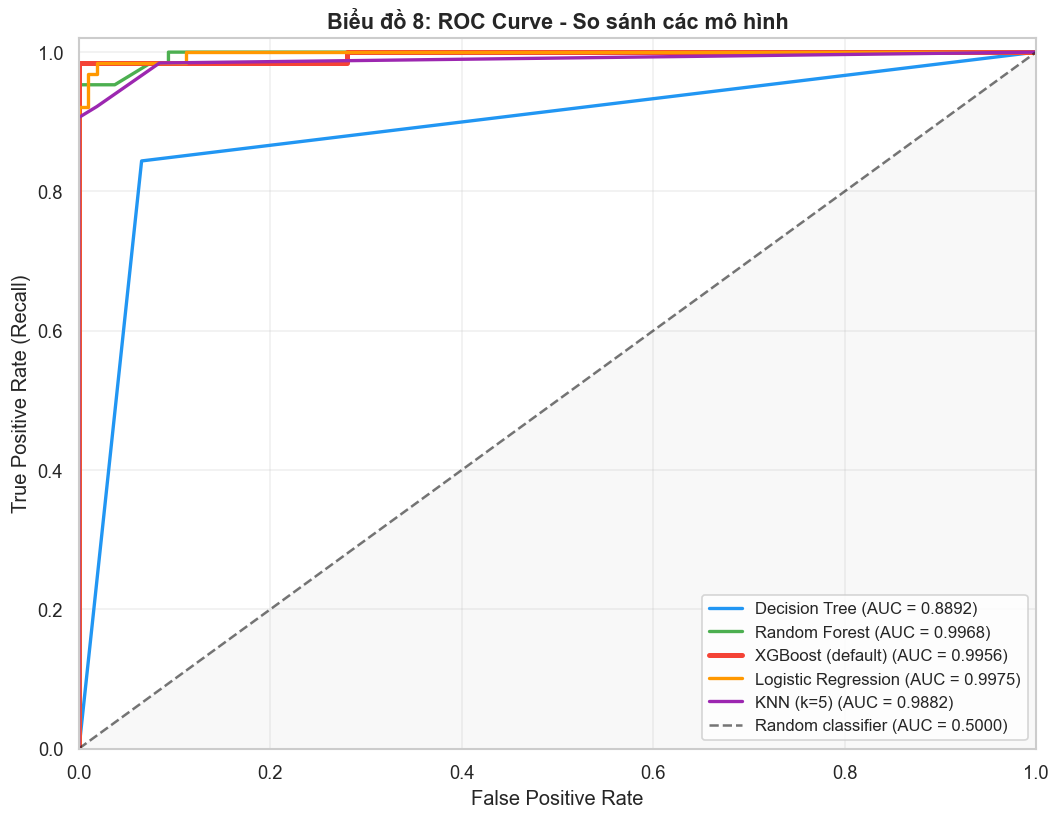

In [ ]:
# Biểu đồ 8: ROC Curves
fig, ax = plt.subplots(figsize=(9, 7))

colors_roc = ['#2196F3', '#4CAF50', '#F44336', '#FF9800', '#9C27B0']
lw_map = {'XGBoost (default)': 3, 'Random Forest': 2, 'Decision Tree': 2, 'Logistic Regression': 2, 'KNN (k=5)': 2}

for result, color in zip(all_results, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, result['y_proba'], pos_label=POS_LABEL)
    auc = result['ROC-AUC']
    lw = lw_map.get(result['Model'], 2)
    ax.plot(fpr, tpr, color=color, lw=lw, label=f"{result['Model']} (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6, label='Random classifier (AUC = 0.5000)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('Biểu đồ 8: ROC Curve - So sánh các mô hình (lớp dương: Malignant = 0)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. (Phụ) Tìm Kiếm Siêu Tham Số Tối Ưu (GridSearchCV)
*Kết quả chính vẫn dựa trên cấu hình mặc định; phần này dùng để tham khảo.*

In [ ]:
print('Bắt đầu GridSearchCV cho XGBoost...')
print('(Quá trình này có thể mất 1-3 phút)')

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_base = XGBClassifier(
    objective='binary:logistic',
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    use_label_encoder=False,
    verbosity=0
)

f1_pos = make_scorer(f1_score, pos_label=POS_LABEL)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring=f1_pos,
    cv=5,
    n_jobs=-1,
    verbose=1
)

start_gs = time.time()
grid_search.fit(X_train, y_train)
gs_time = time.time() - start_gs

print(f'\n✅ GridSearchCV hoàn thành sau {gs_time:.1f}s')
print(f'\n🏆 Best Parameters:')
for k, v in grid_search.best_params_.items():
    print(f'   {k:20s} = {v}')
print(f'\n   Best CV F1-score  = {grid_search.best_score_:.4f}')

Bắt đầu GridSearchCV cho XGBoost...
(Quá trình này có thể mất 1-3 phút)
Fitting 5 folds for each of 108 candidates, totalling 540 fits

✅ GridSearchCV hoàn thành sau 37.3s

🏆 Best Parameters:
   colsample_bytree     = 0.8
   learning_rate        = 0.2
   max_depth            = 2
   n_estimators         = 50
   subsample            = 1.0

   Best CV F1-score  = 0.9510


In [20]:
# Đánh giá mô hình XGBoost tối ưu
best_xgb = grid_search.best_estimator_
result_best_xgb = evaluate_model(best_xgb, X_train, X_test, y_train, y_test, 'XGBoost (tuned)')

# So sánh default vs tuned
xgb_default = next(r for r in all_results if r['Model'] == 'XGBoost (default)')

print('\n===== SO SÁNH XGBoost Default vs Tuned =====')
compare_cols = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
for col in compare_cols:
    diff = result_best_xgb[col] - xgb_default[col]
    sign = '+' if diff >= 0 else ''
    print(f'  {col:15s}: Default={xgb_default[col]:.4f} | Tuned={result_best_xgb[col]:.4f} | Δ={sign}{diff:.4f}')


===== SO SÁNH XGBoost Default vs Tuned =====
  Accuracy       : Default=0.9825 | Tuned=0.9708 | Δ=-0.0117
  Precision      : Default=1.0000 | Tuned=1.0000 | Δ=+0.0000
  Recall         : Default=0.9531 | Tuned=0.9219 | Δ=-0.0312
  F1-score       : Default=0.9760 | Tuned=0.9593 | Δ=-0.0167
  ROC-AUC        : Default=0.9956 | Tuned=0.9942 | Δ=-0.0015


In [ ]:
# Kiểm tra CV: Base vs Tuned (F1-score)
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

xgb_default_cv = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=1.0, colsample_bytree=1.0,
    objective='binary:logistic',
    random_state=RANDOM_STATE, eval_metric='logloss',
    use_label_encoder=False, verbosity=0
 )

f1_pos = make_scorer(f1_score, pos_label=POS_LABEL)
cv_f1_base = cross_val_score(xgb_default_cv, X_train, y_train, scoring=f1_pos, cv=cv, n_jobs=1)
cv_f1_tuned = cross_val_score(best_xgb, X_train, y_train, scoring=f1_pos, cv=cv, n_jobs=1)

print('===== CV F1-score (5-fold, shuffled) =====')
print(f"Base  : mean={cv_f1_base.mean():.4f} ± {cv_f1_base.std():.4f}")
print(f"Tuned : mean={cv_f1_tuned.mean():.4f} ± {cv_f1_tuned.std():.4f}")
print()
print(f"GridSearch best_score_: {grid_search.best_score_:.4f}")

===== CV F1-score (5-fold, shuffled) =====
Base  : mean=0.9342 ± 0.0366
Tuned : mean=0.9305 ± 0.0386

GridSearch best_score_: 0.9510


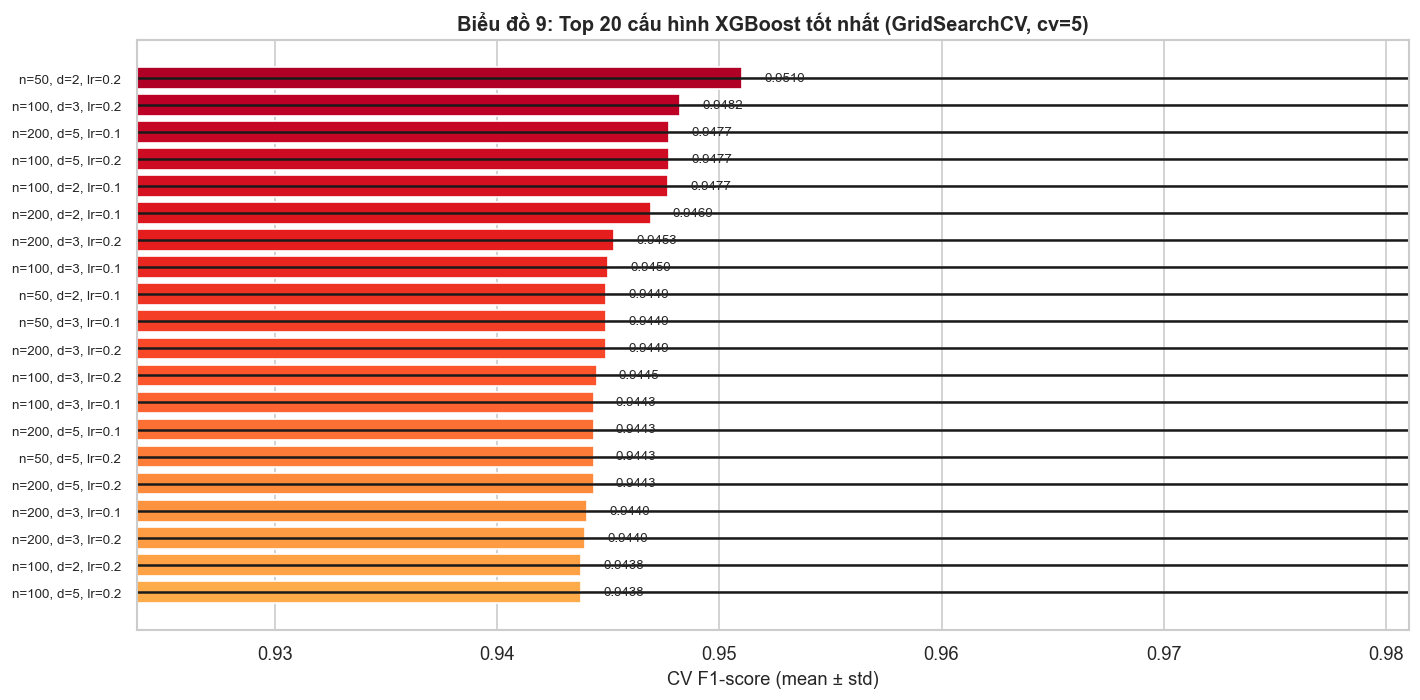

In [21]:
# Biểu đồ 9: Top 20 cấu hình tốt nhất từ GridSearch
cv_results_df = pd.DataFrame(grid_search.cv_results_)
top20 = cv_results_df.nlargest(20, 'mean_test_score').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(top20)), top20['mean_test_score'],
               xerr=top20['std_test_score'],
               color=plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(top20)))[::-1],
               edgecolor='white', capsize=3)

# Label mỗi bar với tham số
for i, row in top20.iterrows():
    params = row['params']
    label = f"n={params['n_estimators']}, d={params['max_depth']}, lr={params['learning_rate']}"
    ax.text(row['mean_test_score'] + 0.001, i, f"{row['mean_test_score']:.4f}",
            va='center', fontsize=8)

ax.set_yticks(range(len(top20)))
ax.set_yticklabels([f"n={r['params']['n_estimators']}, d={r['params']['max_depth']}, lr={r['params']['learning_rate']}" 
                    for _, r in top20.iterrows()], fontsize=8)
ax.set_xlabel('CV F1-score (mean ± std)', fontsize=11)
ax.set_title('Biểu đồ 9: Top 20 cấu hình XGBoost tốt nhất (GridSearchCV, cv=5)',
             fontsize=12, fontweight='bold')
ax.set_xlim(top20['mean_test_score'].min() - 0.02, top20['mean_test_score'].max() + 0.03)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Phân Tích Ảnh Hưởng Tham Số XGBoost

In [ ]:
def param_sweep(param_name, param_values, base_params, X_train, X_test, y_train, y_test):
    """Khảo sát ảnh hưởng của một tham số, giữ cố định các tham số còn lại."""
    records = []
    for val in param_values:
        params = {**base_params, param_name: val}
        model = XGBClassifier(
            **params,
            objective='binary:logistic',
            random_state=RANDOM_STATE,
            eval_metric='logloss',
            use_label_encoder=False,
            verbosity=0
)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        pos_index = int(np.where(model.classes_ == POS_LABEL)[0][0])
        y_proba = model.predict_proba(X_test)[:, pos_index]
        records.append({
            param_name: val,
            'Accuracy': accuracy_score(y_test, y_pred),
            'F1-score': f1_score(y_test, y_pred, pos_label=POS_LABEL),
            'Recall': recall_score(y_test, y_pred, pos_label=POS_LABEL),
            'ROC-AUC': roc_auc_score((y_test == POS_LABEL).astype(int), y_proba)
        })
    return pd.DataFrame(records)


# Cấu hình chính (giữ cố định)
base_config = {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1,
               'subsample': 1.0, 'colsample_bytree': 1.0}

# Khảo sát 3 tham số
df_n_est = param_sweep('n_estimators', [50, 100, 200],
                       {k: v for k, v in base_config.items() if k != 'n_estimators'},
                       X_train, X_test, y_train, y_test)

df_depth = param_sweep('max_depth', [2, 3, 5],
                       {k: v for k, v in base_config.items() if k != 'max_depth'},
                       X_train, X_test, y_train, y_test)

df_lr = param_sweep('learning_rate', [0.01, 0.1, 0.2],
                    {k: v for k, v in base_config.items() if k != 'learning_rate'},
                    X_train, X_test, y_train, y_test)

print('✅ Hoàn thành phân tích tham số!')

✅ Hoàn thành phân tích tham số!


In [ ]:
# Bảng kết quả tham số dạng text
def build_param_table(df_param, param_name):
    out = df_param[[param_name, 'Accuracy', 'F1-score', 'ROC-AUC']].copy()
    out.insert(0, 'Parameter', param_name)
    out.rename(columns={param_name: 'Value'}, inplace=True)
    return out

df_param_table = pd.concat(
    [
        build_param_table(df_n_est, 'n_estimators'),
        build_param_table(df_depth, 'max_depth'),
        build_param_table(df_lr, 'learning_rate'),
    ],
    ignore_index=True
 )

for col in ['Accuracy', 'F1-score', 'ROC-AUC']:
    df_param_table[col] = df_param_table[col].apply(lambda x: f'{x:.4f}')

df_param_table

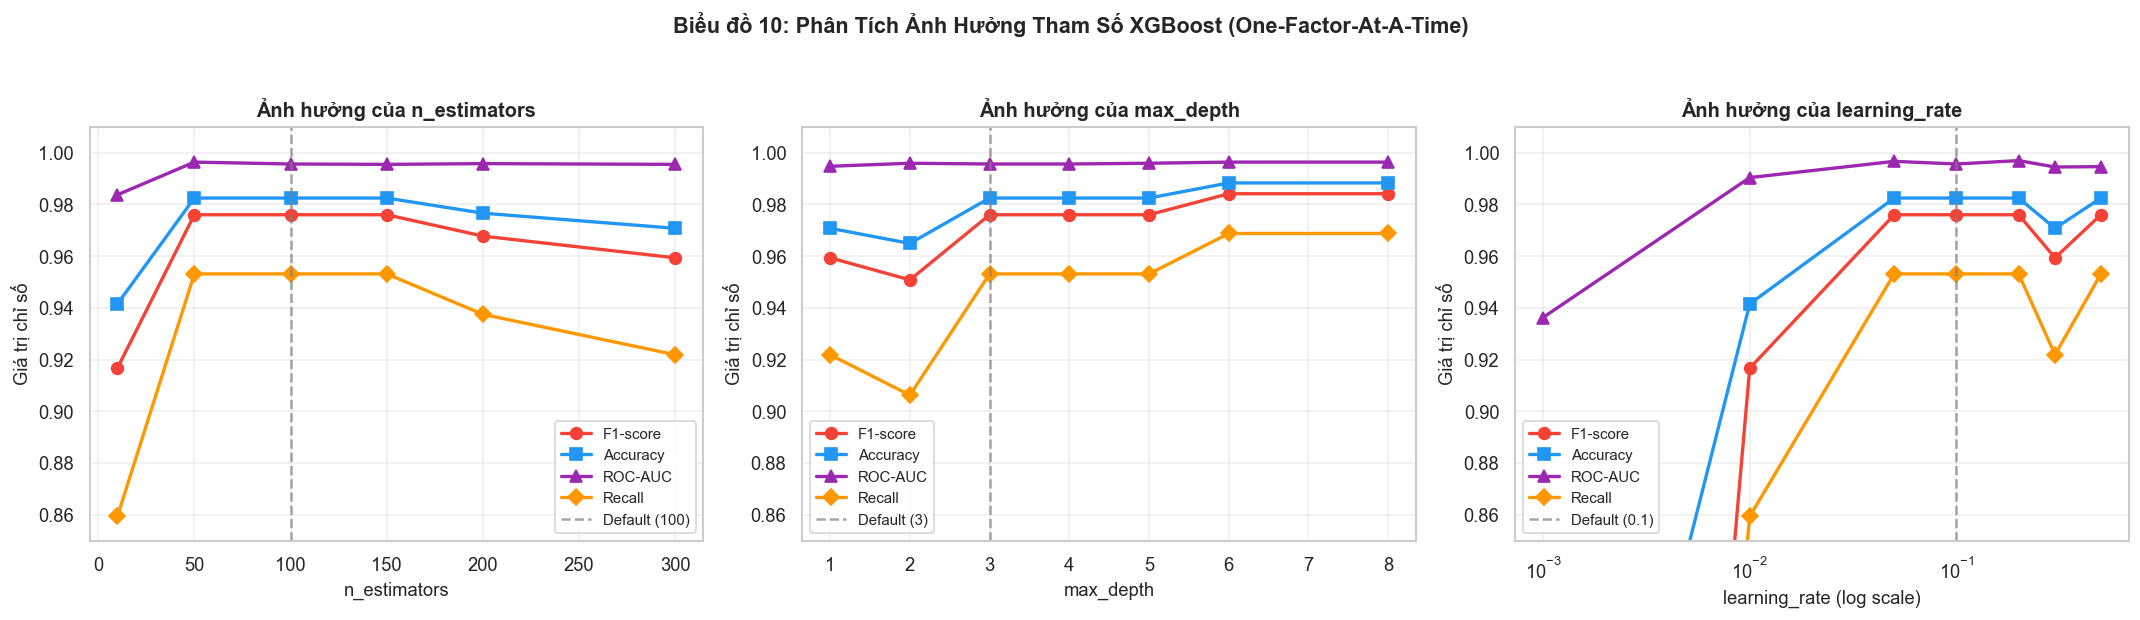

In [23]:
# Biểu đồ 10: Ảnh hưởng tham số XGBoost
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ['F1-score', 'Accuracy', 'ROC-AUC', 'Recall']
colors_line = ['#F44336', '#2196F3', '#9C27B0', '#FF9800']
markers = ['o', 's', '^', 'D']

# Panel 1: n_estimators
for metric, color, marker in zip(metrics_to_plot, colors_line, markers):
    axes[0].plot(df_n_est['n_estimators'], df_n_est[metric],
                 color=color, marker=marker, linewidth=2, markersize=7, label=metric)
axes[0].axvline(x=100, color='gray', linestyle='--', alpha=0.7, linewidth=1.5, label='Default (100)')
axes[0].set_xlabel('n_estimators', fontsize=11)
axes[0].set_ylabel('Giá trị chỉ số', fontsize=11)
axes[0].set_title('Ảnh hưởng của n_estimators', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.85, 1.01)

# Panel 2: max_depth
for metric, color, marker in zip(metrics_to_plot, colors_line, markers):
    axes[1].plot(df_depth['max_depth'], df_depth[metric],
                 color=color, marker=marker, linewidth=2, markersize=7, label=metric)
axes[1].axvline(x=3, color='gray', linestyle='--', alpha=0.7, linewidth=1.5, label='Default (3)')
axes[1].set_xlabel('max_depth', fontsize=11)
axes[1].set_ylabel('Giá trị chỉ số', fontsize=11)
axes[1].set_title('Ảnh hưởng của max_depth', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.85, 1.01)

# Panel 3: learning_rate
for metric, color, marker in zip(metrics_to_plot, colors_line, markers):
    axes[2].semilogx(df_lr['learning_rate'], df_lr[metric],
                     color=color, marker=marker, linewidth=2, markersize=7, label=metric)
axes[2].axvline(x=0.1, color='gray', linestyle='--', alpha=0.7, linewidth=1.5, label='Default (0.1)')
axes[2].set_xlabel('learning_rate (log scale)', fontsize=11)
axes[2].set_ylabel('Giá trị chỉ số', fontsize=11)
axes[2].set_title('Ảnh hưởng của learning_rate', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0.85, 1.01)

plt.suptitle('Biểu đồ 10: Phân Tích Ảnh Hưởng Tham Số XGBoost (One-Factor-At-A-Time)',
             fontsize=13, y=1.03, fontweight='bold')
plt.tight_layout()
plt.show()

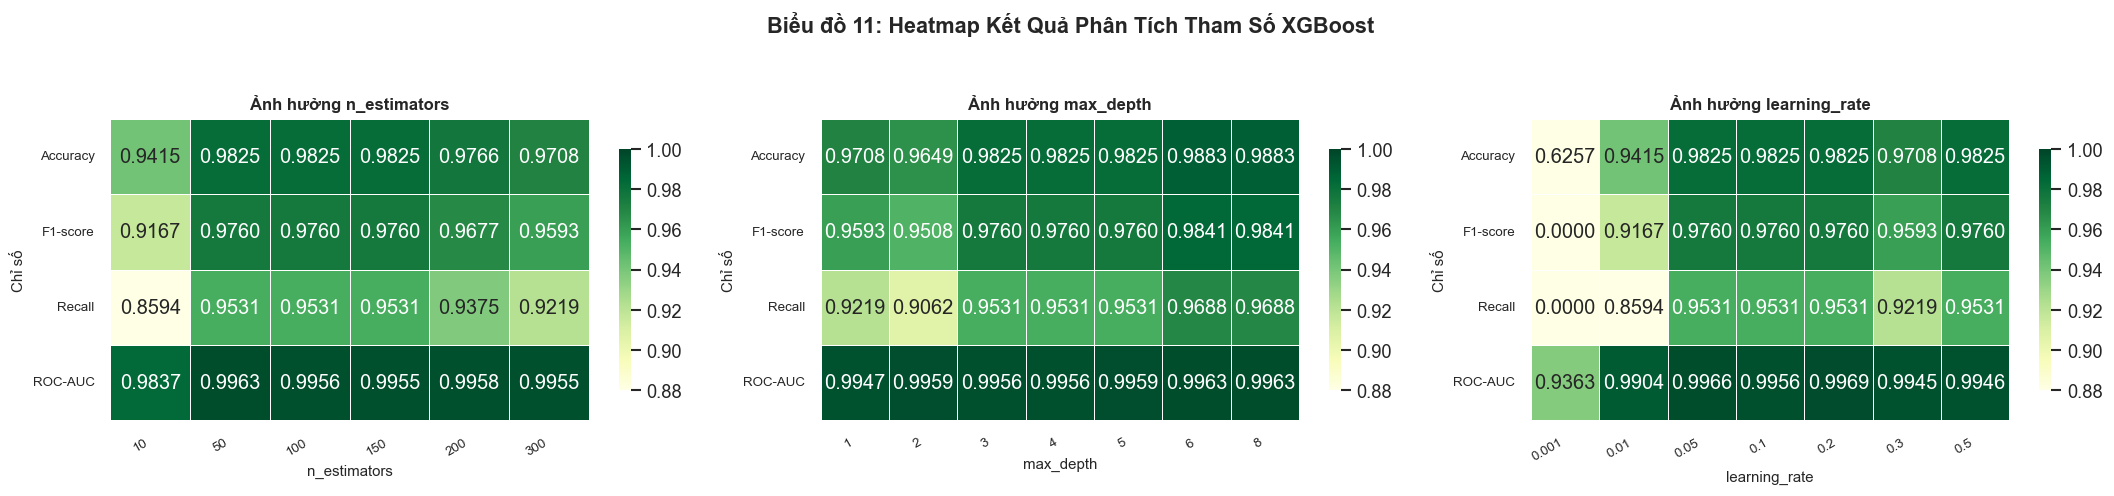

In [24]:
# Biểu đồ 11: Bảng kết quả tham số dạng heatmap
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

datasets_param = [
    (df_n_est, 'n_estimators', 'Ảnh hưởng n_estimators'),
    (df_depth, 'max_depth', 'Ảnh hưởng max_depth'),
    (df_lr, 'learning_rate', 'Ảnh hưởng learning_rate')
]

for ax, (df_p, param, title) in zip(axes, datasets_param):
    hm_data = df_p.set_index(param)[['Accuracy', 'F1-score', 'Recall', 'ROC-AUC']]
    sns.heatmap(hm_data.T, annot=True, fmt='.4f', cmap='YlGn',
                vmin=0.88, vmax=1.0, ax=ax, linewidths=0.5,
                cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel(param, fontsize=9)
    ax.set_ylabel('Chỉ số', fontsize=9)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.suptitle('Biểu đồ 11: Heatmap Kết Quả Phân Tích Tham Số XGBoost',
             fontsize=13, y=1.03, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Feature Importance

In [25]:
# Lấy feature importance từ mô hình XGBoost (cấu hình chính)
xgb_main = next(r['model_obj'] for r in all_results if r['Model'] == 'XGBoost (default)')

fi_gain = pd.Series(xgb_main.get_booster().get_score(importance_type='gain'),
                    name='Gain').sort_values(ascending=False)
fi_weight = pd.Series(xgb_main.get_booster().get_score(importance_type='weight'),
                      name='Weight').sort_values(ascending=False)
fi_cover = pd.Series(xgb_main.get_booster().get_score(importance_type='cover'),
                     name='Cover').sort_values(ascending=False)

top_n = 15
print(f'Top {top_n} đặc trưng quan trọng nhất (theo Gain):')
print(fi_gain.head(top_n).round(2).to_string())

Top 15 đặc trưng quan trọng nhất (theo Gain):
worst perimeter         40.63
mean concave points     23.91
worst concave points     8.37
worst concavity          4.59
mean area                4.44
worst radius             4.39
concavity error          2.52
mean texture             2.46
worst area               2.34
worst smoothness         2.18
worst texture            2.13
mean radius              1.71
area error               1.66
radius error             1.66
compactness error        1.45


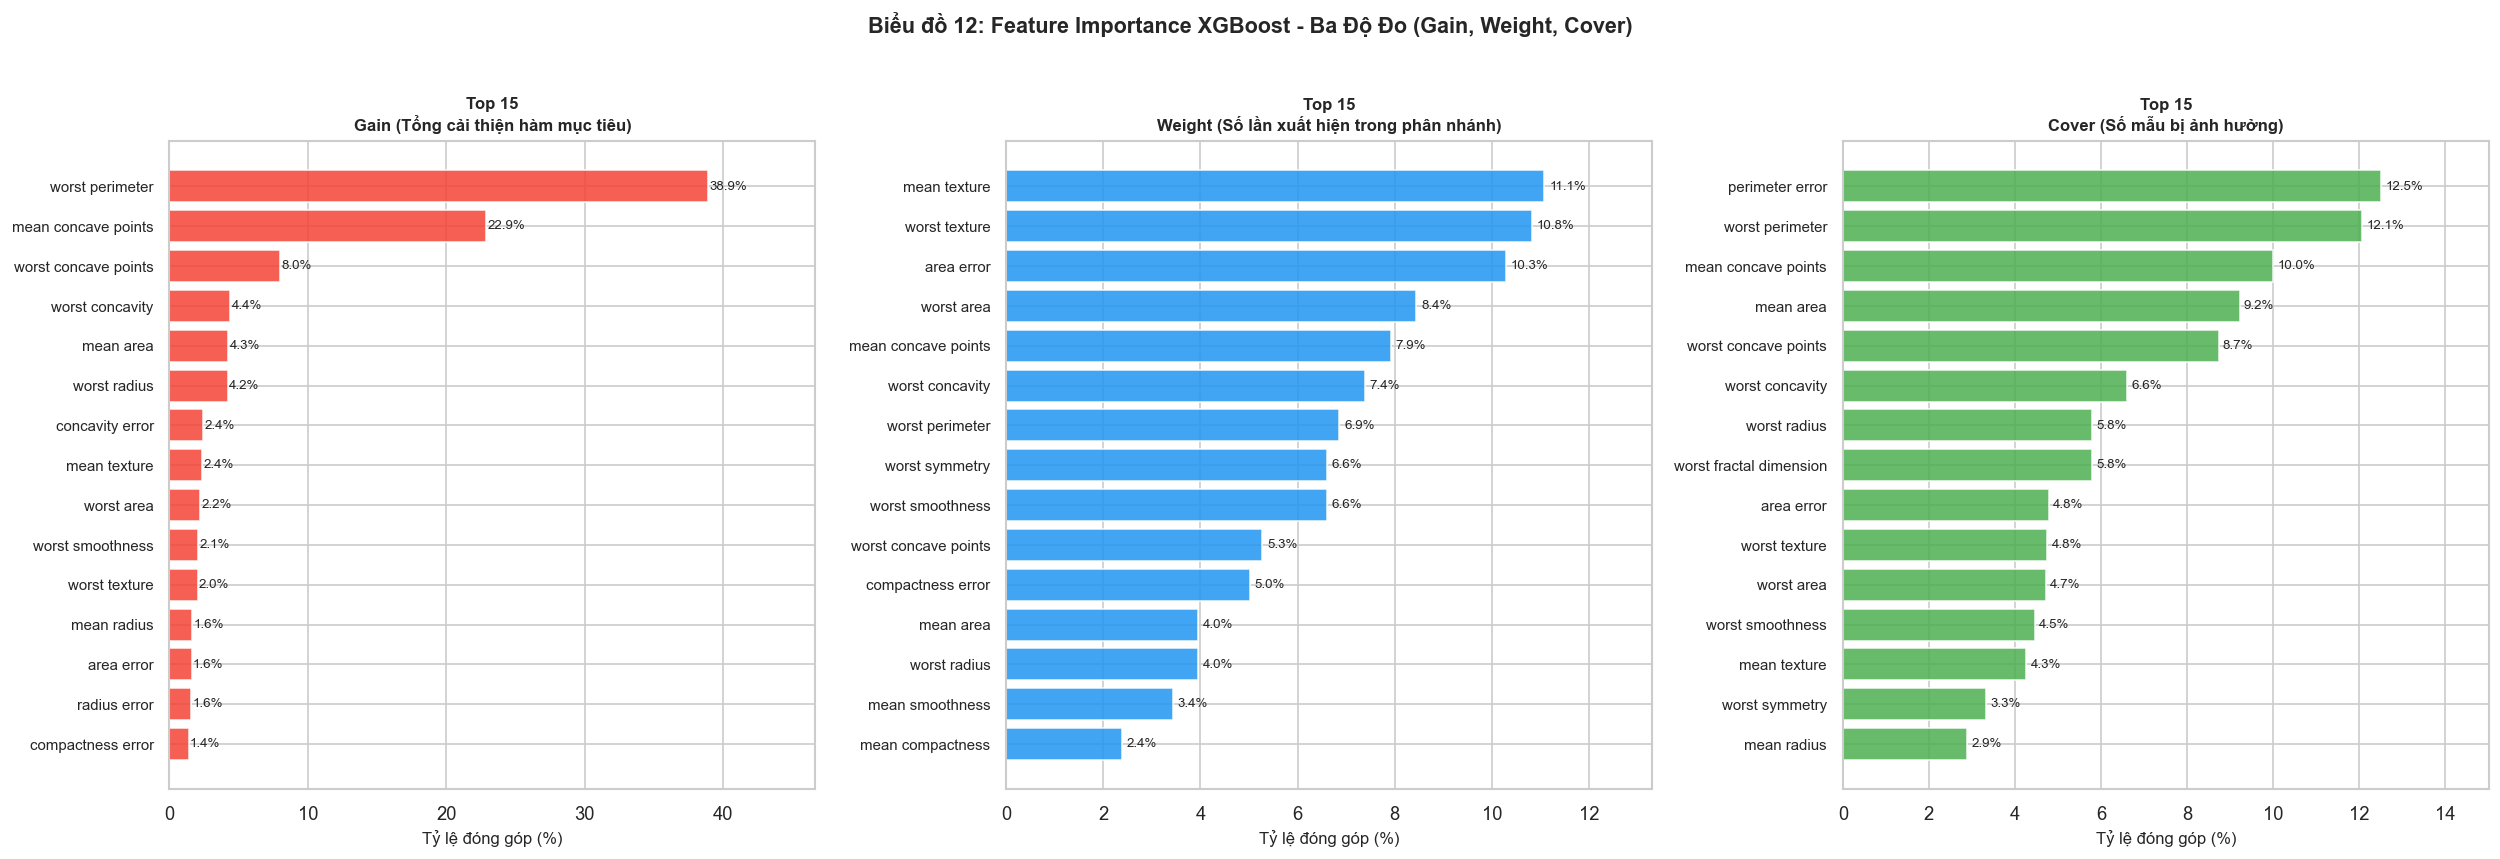

In [26]:
# Biểu đồ 12: Feature Importance - 3 độ đo
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

fi_data = [
    (fi_gain, '#F44336', 'Gain (Tổng cải thiện hàm mục tiêu)'),
    (fi_weight, '#2196F3', 'Weight (Số lần xuất hiện trong phân nhánh)'),
    (fi_cover, '#4CAF50', 'Cover (Số mẫu bị ảnh hưởng)'),
]

for ax, (fi_series, color, title) in zip(axes, fi_data):
    top = fi_series.head(top_n).sort_values()
    # Normalize
    top_norm = top / top.sum() * 100
    bars = ax.barh(range(len(top_norm)), top_norm.values,
                   color=color, alpha=0.85, edgecolor='white')
    ax.set_yticks(range(len(top_norm)))
    ax.set_yticklabels(top_norm.index, fontsize=9)
    ax.set_xlabel('Tỷ lệ đóng góp (%)', fontsize=10)
    ax.set_title(f'Top {top_n}\n{title}', fontsize=10, fontweight='bold')
    for bar, val in zip(bars, top_norm.values):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=8)
    ax.set_xlim(0, top_norm.max() * 1.2)

plt.suptitle('Biểu đồ 12: Feature Importance XGBoost - Ba Độ Đo (Gain, Weight, Cover)',
             fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

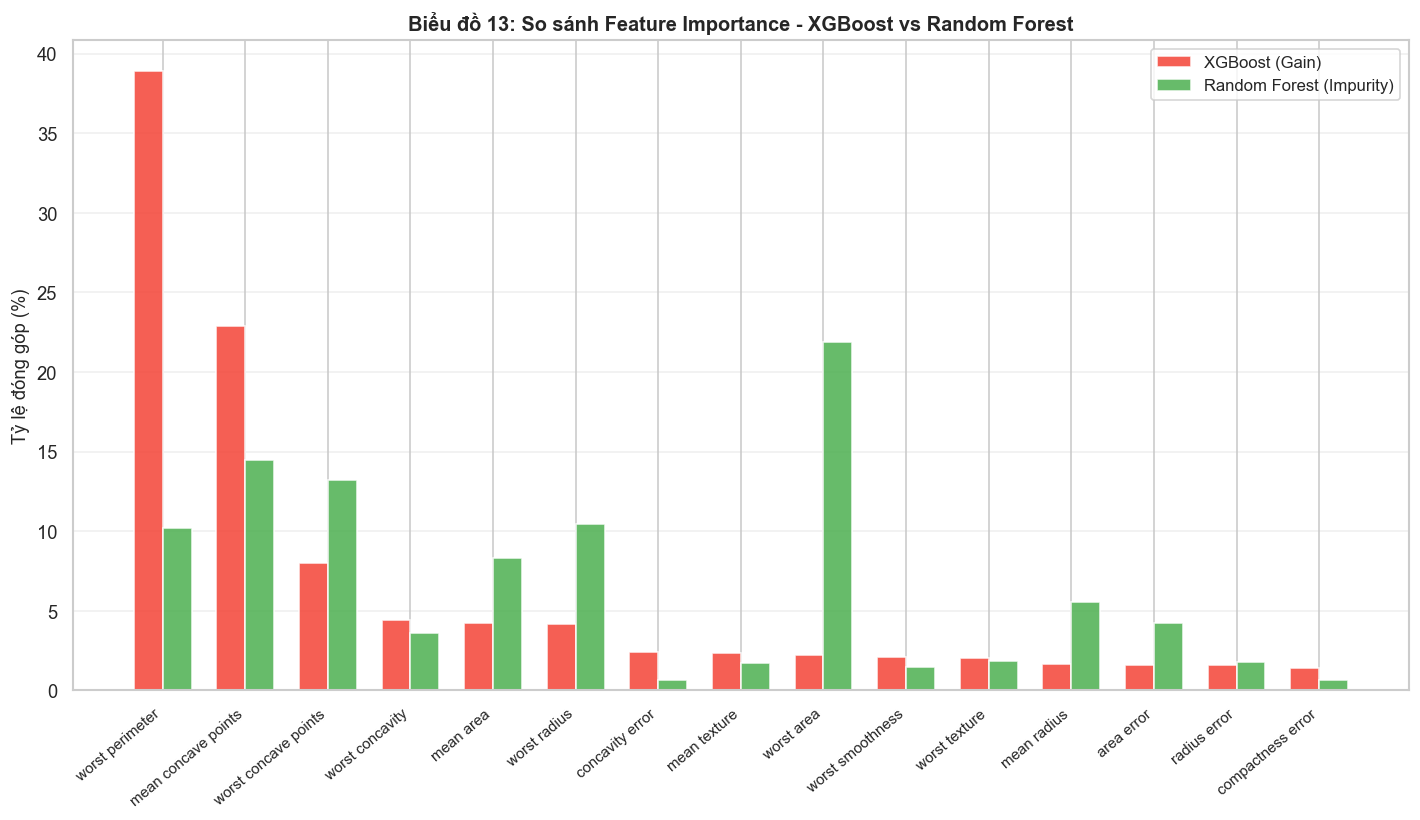

In [27]:
# Biểu đồ 13: So sánh Feature Importance XGBoost vs Random Forest
rf_model = next(r['model_obj'] for r in all_results if r['Model'] == 'Random Forest')
fi_rf = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Lấy top 15 chung
top15_features = list(dict.fromkeys(
    list(fi_gain.head(15).index) + list(fi_rf.head(15).index)
))[:15]

# Normalize
xgb_vals = fi_gain.reindex(top15_features).fillna(0)
xgb_vals = xgb_vals / xgb_vals.sum() * 100
rf_vals = fi_rf.reindex(top15_features).fillna(0)
rf_vals = rf_vals / rf_vals.sum() * 100

fig, ax = plt.subplots(figsize=(12, 7))
x_pos = np.arange(len(top15_features))
w = 0.35

ax.bar(x_pos - w/2, xgb_vals.values, w, label='XGBoost (Gain)', color='#F44336', alpha=0.85, edgecolor='white')
ax.bar(x_pos + w/2, rf_vals.values, w, label='Random Forest (Impurity)', color='#4CAF50', alpha=0.85, edgecolor='white')

ax.set_xticks(x_pos)
ax.set_xticklabels(top15_features, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Tỷ lệ đóng góp (%)', fontsize=11)
ax.set_title('Biểu đồ 13: So sánh Feature Importance - XGBoost vs Random Forest',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Kết Quả Tổng Hợp Và Nhận Xét

In [ ]:
# Bảng tổng hợp chính (không bao gồm XGBoost tuned)
final_metrics = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'Training Time (s)']
df_final = pd.DataFrame(all_results)[final_metrics].copy()

# Highlight best
for col in ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']:
    best_val = df_final[col].max()
    print(f'  Best {col:15s}: {best_val:.4f} → {df_final.loc[df_final[col]==best_val, "Model"].values[0]}')

print()
df_final_display = df_final.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']:
    df_final_display[col] = df_final_display[col].apply(lambda x: f'{x:.4f}')
df_final_display.set_index('Model')

  Best Accuracy       : 0.9825 → XGBoost (default)
  Best Precision      : 1.0000 → Random Forest
  Best Recall         : 0.9531 → XGBoost (default)
  Best F1-score       : 0.9760 → XGBoost (default)
  Best ROC-AUC        : 0.9975 → Logistic Regression



,Accuracy,Precision,Recall,F1-score,ROC-AUC,Training Time (s)
Model,,,,,,
Decision Tree,0.9006,0.8852,0.8438,0.8640,0.8892,0.0091
Random Forest,0.9649,1.0000,0.9062,0.9508,0.9968,0.1648
XGBoost (default),0.9825,1.0000,0.9531,0.9760,0.9956,0.0656
Logistic Regression,0.9708,0.9836,0.9375,0.9600,0.9975,0.0050
XGBoost (tuned),0.9708,1.0000,0.9219,0.9593,0.9942,0.0434


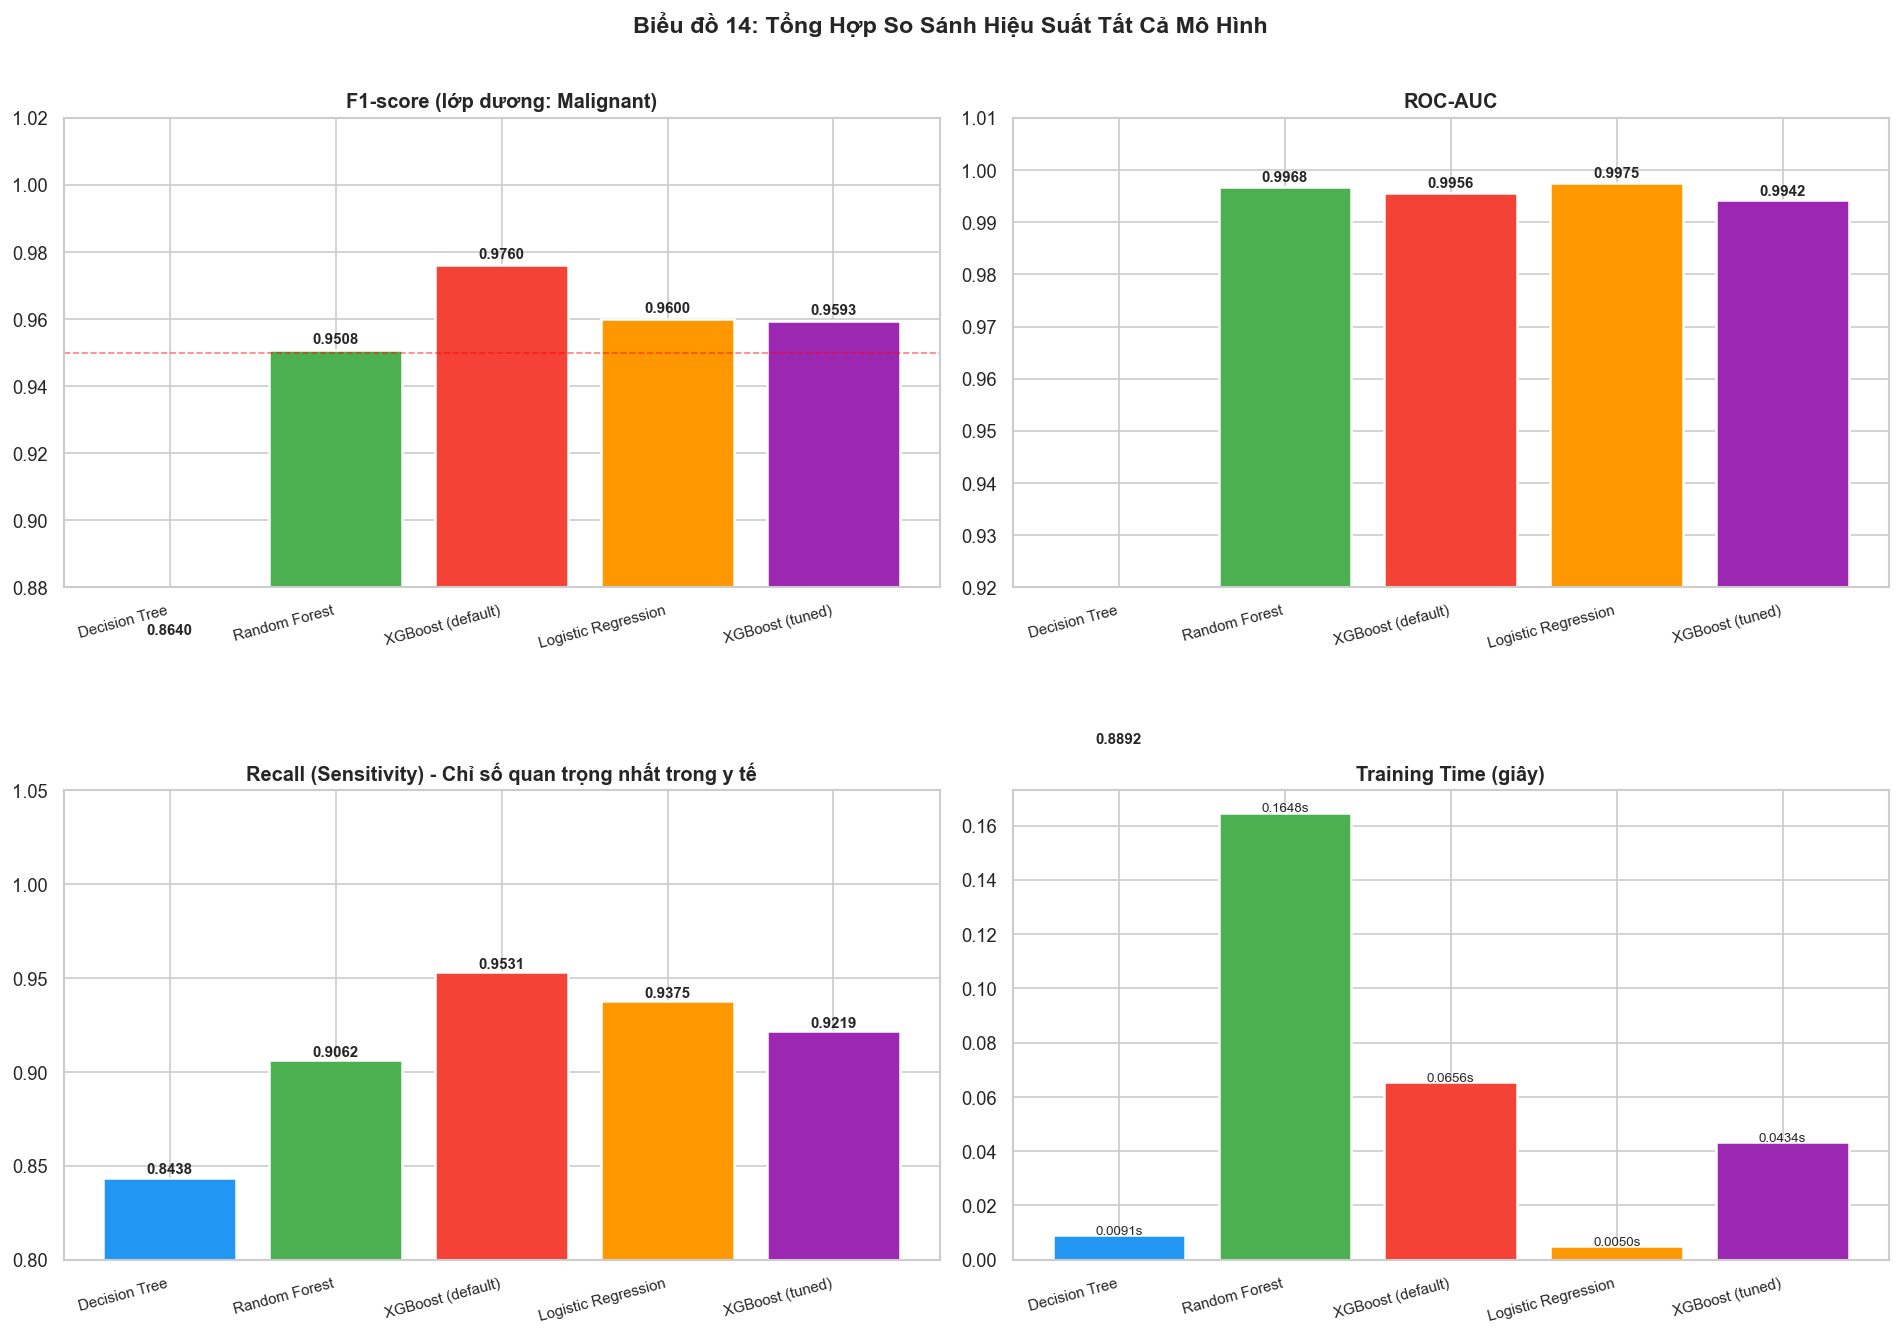

In [ ]:
# Biểu đồ 14: So sánh F1-score và ROC-AUC tất cả mô hình
model_names_main = [r['Model'] for r in all_results]
f1_scores = [r['F1-score'] for r in all_results]
auc_scores = [r['ROC-AUC'] for r in all_results]
recall_scores = [r['Recall'] for r in all_results]
train_times = [r['Training Time (s)'] for r in all_results]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
color_palette = ['#2196F3', '#4CAF50', '#F44336', '#FF9800', '#9C27B0', '#00BCD4']

# Panel 1: F1-score
bars = axes[0, 0].bar(model_names_main, f1_scores, color=color_palette, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, f1_scores):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[0, 0].set_ylim(0.88, 1.02)
axes[0, 0].set_title('F1-score (lớp dương: Malignant = 0)', fontweight='bold')
axes[0, 0].set_xticklabels(model_names_main, rotation=15, ha='right', fontsize=9)
axes[0, 0].axhline(y=0.95, color='red', linestyle='--', alpha=0.5, linewidth=1)

# Panel 2: ROC-AUC
bars2 = axes[0, 1].bar(model_names_main, auc_scores, color=color_palette, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, auc_scores):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[0, 1].set_ylim(0.92, 1.01)
axes[0, 1].set_title('ROC-AUC', fontweight='bold')
axes[0, 1].set_xticklabels(model_names_main, rotation=15, ha='right', fontsize=9)

# Panel 3: Recall
bars3 = axes[1, 0].bar(model_names_main, recall_scores, color=color_palette, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars3, recall_scores):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[1, 0].set_ylim(0.80, 1.05)
axes[1, 0].set_title('Recall (Sensitivity) - Chỉ số quan trọng nhất trong y tế', fontweight='bold')
axes[1, 0].set_xticklabels(model_names_main, rotation=15, ha='right', fontsize=9)

# Panel 4: Training Time
bars4 = axes[1, 1].bar(model_names_main, train_times, color=color_palette, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars4, train_times):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
                    f'{val:.4f}s', ha='center', fontsize=8)
axes[1, 1].set_title('Training Time (giây)', fontweight='bold')
axes[1, 1].set_xticklabels(model_names_main, rotation=15, ha='right', fontsize=9)

plt.suptitle('Biểu đồ 14: Tổng Hợp So Sánh Hiệu Suất Tất Cả Mô Hình',
             fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Tổng kết cuối
print('=' * 65)
print('  TỔNG KẾT THỰC NGHIỆM')
print('=' * 65)
print(f'  Dataset     : UCI Breast Cancer Wisconsin Diagnostic')
print(f'  Số mẫu      : 569 (Train: 398 | Test: 171)')
print(f'  Chia dữ liệu: 70/30 Stratified, random_state=42')
print(f'  Lớp dương   : Malignant (0)')
print()

for r in all_results:
    print(f"  {r['Model']:25s} | F1={r['F1-score']:.4f} | AUC={r['ROC-AUC']:.4f} | Recall={r['Recall']:.4f}")

print()
best_f1_model = max(all_results, key=lambda r: r['F1-score'])
best_auc_model = max(all_results, key=lambda r: r['ROC-AUC'])
print(f'  🏆 Best F1-score : {best_f1_model["Model"]} ({best_f1_model["F1-score"]:.4f})')
print(f'  🏆 Best ROC-AUC  : {best_auc_model["Model"]} ({best_auc_model["ROC-AUC"]:.4f})')
print('=' * 65)
print()
print('  Top 5 đặc trưng quan trọng nhất (XGBoost Gain):')
for i, (feat, val) in enumerate(fi_gain.head(5).items(), 1):
    print(f'    {i}. {feat:35s} Gain = {val:.1f}')
print('=' * 65)

  TỔNG KẾT THỰC NGHIỆM
  Dataset     : UCI Breast Cancer Wisconsin Diagnostic
  Số mẫu      : 569 (Train: 398 | Test: 171)
  Chia dữ liệu: 70/30 Stratified, random_state=42
  Lớp dương   : Malignant (1)

  Decision Tree             | F1=0.8640 | AUC=0.8892 | Recall=0.8438
  Random Forest             | F1=0.9508 | AUC=0.9968 | Recall=0.9062
  XGBoost (default)         | F1=0.9760 | AUC=0.9956 | Recall=0.9531
  Logistic Regression       | F1=0.9600 | AUC=0.9975 | Recall=0.9375
  XGBoost (tuned)           | F1=0.9593 | AUC=0.9942 | Recall=0.9219

  🏆 Best F1-score : XGBoost (default) (0.9760)
  🏆 Best ROC-AUC  : Logistic Regression (0.9975)

  Top 5 đặc trưng quan trọng nhất (XGBoost Gain):
    1. worst perimeter                     Gain = 40.6
    2. mean concave points                 Gain = 23.9
    3. worst concave points                Gain = 8.4
    4. worst concavity                     Gain = 4.6
    5. mean area                           Gain = 4.4
